In [14]:
import pandas as pd

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Load your dataset
df_sample = pd.read_csv('/content/drive/MyDrive/ LLM application for Maintenance Decision Making/Data/sample_df_500.csv')

In [17]:
df_sample.shape

(500, 21)

In [18]:
df_sample.columns

Index(['AADT', 'AADT Single Unit', 'AADT Combination', 'Future AADT',
       'International Roughness Index', 'Thickness of Rigid Pavements',
       'Thickness of Flexible Pavements', 'Thickness of Base Pavements',
       'Functional System', 'Urban Type', 'Surface Type', 'Base Type',
       'Rutting', 'Cracking Percent', 'Faulting', 'Relative Humidity',
       'Freezing Index', 'Average Temperature', 'Precipitation', 'Age',
       'Maintenance Intervention'],
      dtype='object')

In [19]:
df_sample['Maintenance Intervention'].value_counts()

,count
Maintenance Intervention,
No Maintenance,255
Thin Overlay,178
Thick Overlay,53
Resurfacing,14


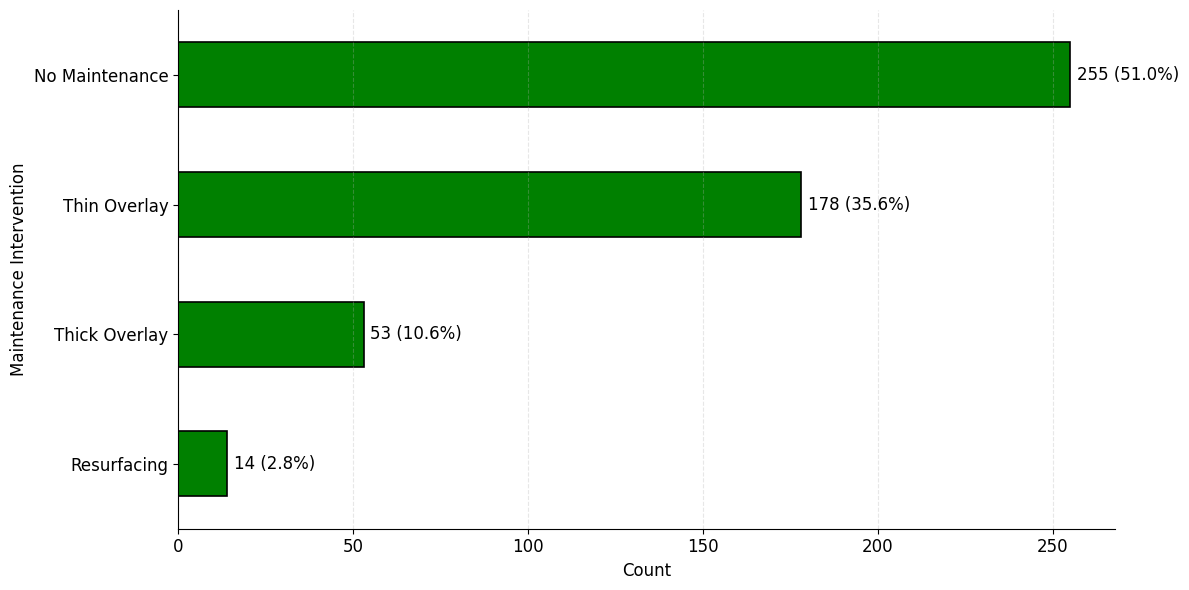

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set Times New Roman for all text
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Count and sort: highest bar on top
maintenance_counts = (
    df_sample['Maintenance Intervention']
    .value_counts()
    .sort_values(ascending=False)
)

total = maintenance_counts.sum()

fig, ax = plt.subplots(figsize=(12, 6))

bars = maintenance_counts.plot(
    kind='barh',
    ax=ax,
    color='green',
    edgecolor='black',
    linewidth=1.2
)

# Put largest category at the top
ax.invert_yaxis()

# Add count and percentage labels
for p in ax.patches:
    count = int(p.get_width())
    pct = 100 * count / total

    ax.annotate(
        f'{count} ({pct:.1f}%)',
        (p.get_width(), p.get_y() + p.get_height()/2),
        xytext=(5, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=12,
        fontname='Times New Roman'
    )

# Publication style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.3)

ax.set_xlabel('Count', fontsize=12, fontname='Times New Roman')
ax.set_ylabel('Maintenance Intervention', fontsize=12, fontname='Times New Roman')

# Times New Roman for tick labels
for label in ax.get_xticklabels():
    label.set_fontname('Times New Roman')
    label.set_fontsize(12)

for label in ax.get_yticklabels():
    label.set_fontname('Times New Roman')
    label.set_fontsize(12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()